# INSTALAMOS KERAS TUNER

In [1]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.5 MB/s eta 0:00:00


# IMPORTAMOS LIBREARIAS

In [2]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CARGAMOS EL DATASET

In [4]:
df = pd.read_csv('/content/water_potability.csv')
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [5]:
df['Potability'].value_counts()

,count
Potability,
0,1998
1,1278


# IMPUTACIÓN DE NULOS

In [6]:
for col in ['ph','Sulfate','Trihalomethanes']:
  df[col].fillna(df[col].mean(),inplace=True)

df.isnull().sum()

/tmp/ipython-input-1535639780.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace=True)


,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


# TRAIN TEST SPLIT Y ESCALAMIENTO

In [7]:
X = df.drop(columns=["Potability"])
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# CONSTRUIMOS UN MODELO DE HIPERPARAMETROS AJUSTABLES

In [8]:
def build_model(hp):
  model = keras.Sequential()
  model.add(keras.layers.Dense(hp.Int("units1", min_value=16, max_value=500, step=80), activation="relu", input_shape=(X_train_scaled.shape[1],)))
  model.add(keras.layers.Dense(hp.Int("units2",min_value=16,max_value=500,step=80),activation='relu'))
  model.add(keras.layers.Dense(1,activation='sigmoid'))

  model.compile(
      optimizer=keras.optimizers.RMSprop(hp.Choice("learning_rate",[0.001,0.01,0.1])),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  return model

# CREAMOS OBJETO DE KERAS TUNER

In [9]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=15,
    factor=3,
    directory='kt_search',
    project_name='water_potability'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
tuner.search(X_train_scaled,y_train,epochs=20,validation_data=(X_test_scaled,y_test))

Trial 30 Complete [00h 00m 08s]
val_accuracy: 0.6798780560493469

Best val_accuracy So Far: 0.6798780560493469
Total elapsed time: 00h 02m 25s


# MOSTRAMOS LOS MEJORES HIPERPARAMETROS

In [11]:
# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Mejor configuración: {best_hps.values}")

Mejor configuración: {'units1': 496, 'units2': 256, 'learning_rate': 0.01, 'tuner/epochs': 15, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}


# CREAMOS UN MODELO CON LOS MEJORES HIPERPARAMETROS

In [29]:
# Entrenar el mejor modelo encontrado
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train_scaled, y_train, epochs=3, validation_data=(X_test_scaled, y_test))

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5738 - loss: 0.7746 - val_accuracy: 0.6463 - val_loss: 0.6733
Epoch 2/3
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6557 - loss: 0.6226 - val_accuracy: 0.6723 - val_loss: 0.6353
Epoch 3/3
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6659 - loss: 0.6210 - val_accuracy: 0.6540 - val_loss: 0.6288


In [23]:
def plot_overfitting(history):
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(epochs, history.history['val_loss'], label='Pérdida de validación')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.title('Pérdida en entrenamiento vs validación')

    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(epochs, history.history['val_accuracy'], label='Precisión de validación')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    plt.title('Precisión en entrenamiento vs validación')

    plt.show()

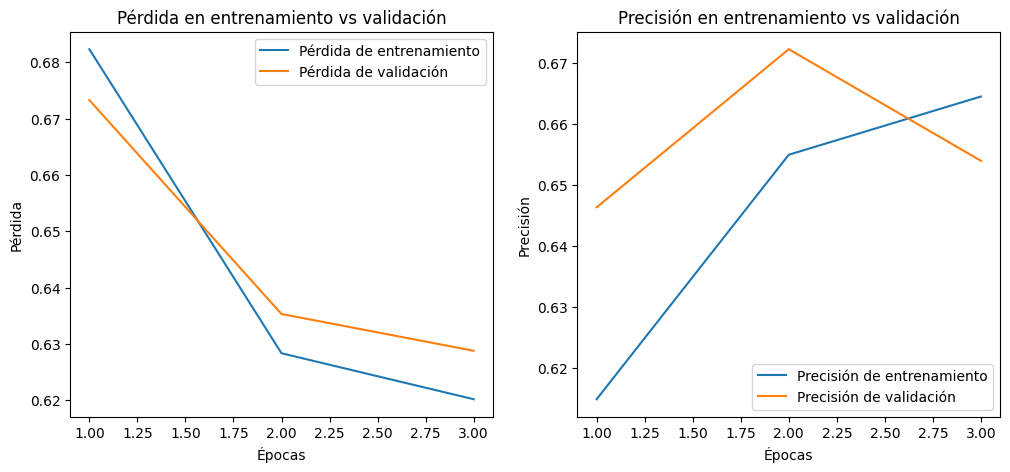

In [30]:
plot_overfitting(history)

In [31]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)
y_pred = np.round(y_pred)

score = accuracy_score(y_test,y_pred)
print(f'el accuracy es {score}')

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
el accuracy es 0.3902439024390244


<Figure size 1100x1100 with 0 Axes>

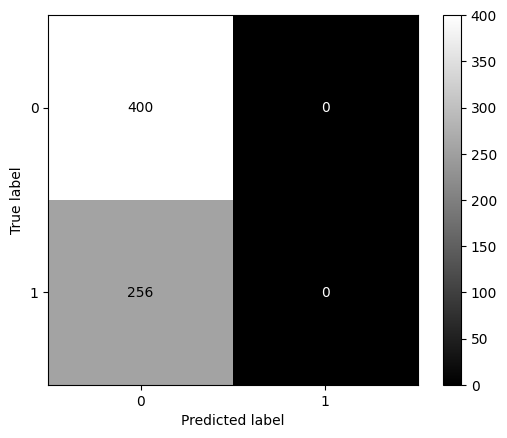

In [16]:
matrix = confusion_matrix(y_test,y_pred)
fig = plt.figure(figsize=(11,11))
cm = matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='gray')
plt.show()